In [1]:
# ============================================================
# 1. Import Libraries
# ============================================================
# Philosophy:
#
# This notebook performs exploratory data analysis
# and data engineering validation for the diabetes
# readmission project.
#
# Unlike the orchestrator notebook, this notebook
# is not responsible for running the CI/CD pipeline.
#
# It focuses on:
#
# - understanding the raw dataset
# - validating missing values and target imbalance
# - uploading raw data to S3
# - querying raw data with Athena
# - creating a SageMaker Feature Store feature group
# - generating EDA charts for the final report
# ============================================================

import os
import re
import time
import json
import boto3
import sagemaker

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
# ============================================================
# 2. Project Configuration
# ============================================================
# Philosophy:
#
# Configuration values are grouped in one place so
# the notebook is easier to maintain.
#
# These settings match the final ML pipeline design
# and keep the EDA notebook consistent with the
# preprocessing and training workflow.
# ============================================================

RAW_FILE = "../diabetic_data.csv"

TARGET = "readmitted"

RANDOM_STATE = 42

SAMPLE_SIZE = 15000

PRODUCTION_SIZE = 6000

ATHENA_DATABASE = "aai540_diabetes_db"

ATHENA_TABLE = "diabetes_raw"

FEATURE_GROUP_NAME = "diabetes-readmission-feature-group"

FEATURES = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "insulin"
]

print("Raw file:", RAW_FILE)
print("Target:", TARGET)
print("Selected features:", len(FEATURES))

Raw file: ../diabetic_data.csv
Target: readmitted
Selected features: 19


In [3]:
# ============================================================
# 3. SageMaker and AWS Setup
# ============================================================
# Philosophy:
#
# The project stores raw data and generated outputs
# in Amazon S3.
#
# The bucket name is generated dynamically using
# the AWS account ID so the notebook can run in
# different AWS lab environments without hardcoding
# a bucket name.
# ============================================================

session = sagemaker.Session()

REGION = session.boto_region_name

role = sagemaker.get_execution_role()

account_id = boto3.client(
    "sts",
    region_name=REGION
).get_caller_identity()["Account"]

BUCKET_NAME = f"aai540-diabetes-readmission-{account_id}"

s3 = boto3.client(
    "s3",
    region_name=REGION
)

try:
    s3.head_bucket(Bucket=BUCKET_NAME)

    print("Bucket already exists:")
    print(BUCKET_NAME)

except Exception:

    if REGION == "us-east-1":
        s3.create_bucket(Bucket=BUCKET_NAME)

    else:
        s3.create_bucket(
            Bucket=BUCKET_NAME,
            CreateBucketConfiguration={
                "LocationConstraint": REGION
            }
        )

    print("Bucket created:")
    print(BUCKET_NAME)

print("\nRegion:", REGION)
print("Role:", role)
print("Bucket:", BUCKET_NAME)

Bucket already exists:
aai540-diabetes-readmission-468962265940

Region: us-east-1
Role: arn:aws:iam::468962265940:role/LabRole
Bucket: aai540-diabetes-readmission-468962265940


In [4]:
# ============================================================
# 4. Load Raw Dataset
# ============================================================
# Philosophy:
#
# The raw dataset is loaded before cleaning so we
# can inspect the original structure.
#
# This confirms:
#
# - the file exists
# - row and column count
# - original feature names
# - sample records
# ============================================================

df = pd.read_csv(RAW_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# ============================================================
# 5. Upload Raw Dataset to S3 Data Lake
# ============================================================
# Philosophy:
#
# The raw dataset is stored in S3 to represent the
# project's data lake layer.
#
# This supports the data engineering requirement
# and allows Athena to query the raw data directly
# from S3.
# ============================================================

raw_s3_key = "raw/diabetes/diabetic_data.csv"

s3.upload_file(
    RAW_FILE,
    BUCKET_NAME,
    raw_s3_key
)

raw_data_s3_uri = f"s3://{BUCKET_NAME}/{raw_s3_key}"

print("Raw dataset uploaded to S3:")
print(raw_data_s3_uri)

Raw dataset uploaded to S3:
s3://aai540-diabetes-readmission-468962265940/raw/diabetes/diabetic_data.csv


In [6]:
# ============================================================
# 6. Dataset Overview
# ============================================================
# Philosophy:
#
# Before feature engineering, we inspect basic
# dataset properties.
#
# This helps identify data quality issues and
# confirms that the dataset matches the expected
# project scope.
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nBasic summary:")
display(df.describe(include="all").T)

Dataset shape:
(101766, 50)

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         


Basic summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Columns containing '?' placeholders:


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

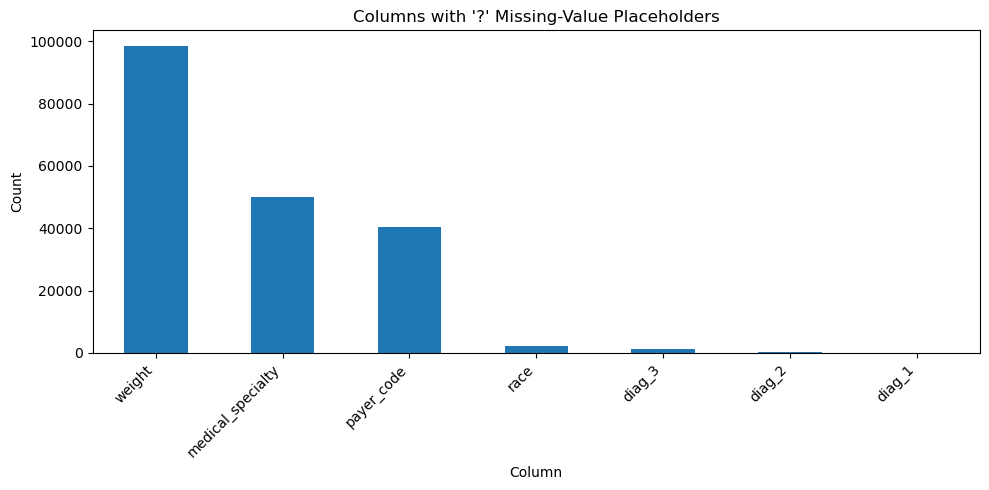

In [7]:
# ============================================================
# 7. Missing Placeholder Analysis
# ============================================================
# Philosophy:
#
# The UCI diabetes dataset uses "?" as a placeholder
# for missing values.
#
# This is important because "?" is not a clinically
# meaningful category and should not be treated as
# a valid model input.
#
# This analysis directly supports the preprocessing
# decision to replace "?" with NaN.
# ============================================================

missing_placeholder_counts = (df == "?").sum()

missing_placeholder_counts = missing_placeholder_counts[
    missing_placeholder_counts > 0
].sort_values(ascending=False)

print("Columns containing '?' placeholders:")
display(missing_placeholder_counts)

plt.figure(figsize=(10, 5))
missing_placeholder_counts.plot(kind="bar")
plt.title("Columns with '?' Missing-Value Placeholders")
plt.xlabel("Column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 8. Convert "?" to Missing Values
# ============================================================
# Philosophy:
#
# After identifying placeholder values, we convert
# "?" into NaN.
#
# This creates a cleaner dataframe for EDA and
# matches the preprocessing logic later used in the
# SageMaker Pipeline.
# ============================================================

df_clean = df.replace("?", np.nan)

missing_values = df_clean.isna().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("Missing values after replacing '?' with NaN:")
display(missing_values)

Missing values after replacing '?' with NaN:


weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

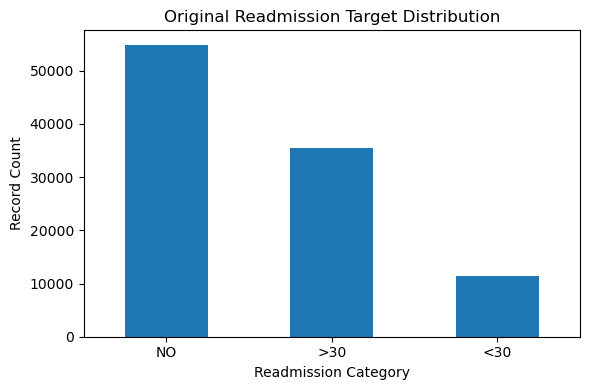

In [9]:
# ============================================================
# 9. Target Distribution Visualization
# ============================================================
# Philosophy:
#
# Understanding the target variable is one of the
# most important steps before model training.
#
# This visualization helps us:
#
# - identify class imbalance
# - understand readmission outcome frequency
# - verify that the target column was loaded correctly
#
# In this dataset:
#
# - NO   = no readmission
# - >30  = readmitted after 30 days
# - <30  = readmitted within 30 days
# ============================================================

target_counts = df_clean[TARGET].value_counts()

display(target_counts)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Original Readmission Target Distribution")
plt.xlabel("Readmission Category")
plt.ylabel("Record Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3593/62240971.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["readmitted_binary"] = df_clean[TARGET].replace({


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

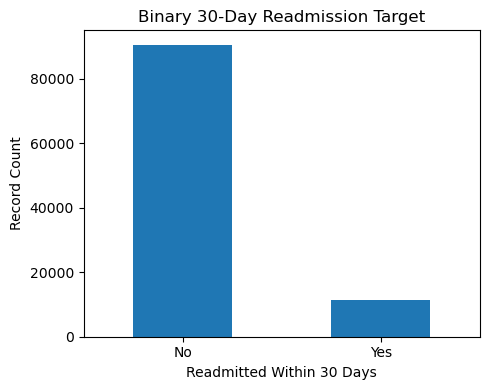

In [10]:
# ============================================================
# 10. Binary Target Conversion
# ============================================================
# Philosophy:
#
# The project predicts whether a patient is
# readmitted within 30 days.
#
# Therefore, the original three-class target is
# converted into a binary classification target:
#
# - <30 = 1
# - >30 = 0
# - NO  = 0
#
# This binary target is used consistently in model
# training, evaluation, monitoring, and CI/CD.
# ============================================================

df_clean["readmitted_binary"] = df_clean[TARGET].replace({
    "<30": 1,
    ">30": 0,
    "NO": 0
}).astype(int)

binary_counts = df_clean["readmitted_binary"].value_counts().sort_index()

display(binary_counts)

plt.figure(figsize=(5, 4))
binary_counts.plot(kind="bar")
plt.title("Binary 30-Day Readmission Target")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Record Count")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 11. Athena Query Helper
# ============================================================
# Philosophy:
#
# Athena allows SQL queries directly on raw data
# stored in S3.
#
# This helper function runs Athena queries and waits
# until the query completes.
#
# Athena is used in this EDA notebook as a data
# engineering and SQL-based validation layer, not as
# the training mechanism for the model.
# ============================================================

def run_athena_query(
    query,
    database,
    output_location,
    region
):
    athena = boto3.client(
        "athena",
        region_name=region
    )

    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={
            "Catalog": "AwsDataCatalog",
            "Database": database
        },
        ResultConfiguration={
            "OutputLocation": output_location
        }
    )

    query_execution_id = response["QueryExecutionId"]

    while True:
        result = athena.get_query_execution(
            QueryExecutionId=query_execution_id
        )

        status = result["QueryExecution"]["Status"]["State"]

        if status in ["SUCCEEDED", "FAILED", "CANCELLED"]:
            break

        time.sleep(2)

    if status != "SUCCEEDED":
        raise RuntimeError(
            result["QueryExecution"]["Status"]
        )

    return query_execution_id

In [12]:
# ============================================================
# 12. Create Athena Database and External Table
# ============================================================
# Philosophy:
#
# Athena uses the AWS Glue Data Catalog to define
# table metadata over files stored in S3.
#
# This allows the raw diabetes CSV to be queried
# with SQL while staying in the S3 data lake.
#
# This demonstrates the project's data engineering
# layer before model training begins.
# ============================================================

athena_output = f"s3://{BUCKET_NAME}/athena-query-results/"

create_db_query = f"""
CREATE DATABASE IF NOT EXISTS {ATHENA_DATABASE}
"""

run_athena_query(
    query=create_db_query,
    database="default",
    output_location=athena_output,
    region=REGION
)

create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {ATHENA_DATABASE}.{ATHENA_TABLE} (
    encounter_id BIGINT,
    patient_nbr BIGINT,
    race STRING,
    gender STRING,
    age STRING,
    weight STRING,
    admission_type_id INT,
    discharge_disposition_id INT,
    admission_source_id INT,
    time_in_hospital INT,
    payer_code STRING,
    medical_specialty STRING,
    num_lab_procedures INT,
    num_procedures INT,
    num_medications INT,
    number_outpatient INT,
    number_emergency INT,
    number_inpatient INT,
    diag_1 STRING,
    diag_2 STRING,
    diag_3 STRING,
    number_diagnoses INT,
    max_glu_serum STRING,
    A1Cresult STRING,
    metformin STRING,
    repaglinide STRING,
    nateglinide STRING,
    chlorpropamide STRING,
    glimepiride STRING,
    acetohexamide STRING,
    glipizide STRING,
    glyburide STRING,
    tolbutamide STRING,
    pioglitazone STRING,
    rosiglitazone STRING,
    acarbose STRING,
    miglitol STRING,
    troglitazone STRING,
    tolazamide STRING,
    examide STRING,
    citoglipton STRING,
    insulin STRING,
    glyburide_metformin STRING,
    glipizide_metformin STRING,
    glimepiride_pioglitazone STRING,
    metformin_rosiglitazone STRING,
    metformin_pioglitazone STRING,
    change STRING,
    diabetesMed STRING,
    readmitted STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    "separatorChar" = ",",
    "quoteChar" = "\\""
)
LOCATION 's3://{BUCKET_NAME}/raw/diabetes/'
TBLPROPERTIES (
    "skip.header.line.count" = "1"
)
"""

run_athena_query(
    query=create_table_query,
    database=ATHENA_DATABASE,
    output_location=athena_output,
    region=REGION
)

print("Athena database and table created or reused.")
print(f"Database: {ATHENA_DATABASE}")
print(f"Table: {ATHENA_TABLE}")

Athena database and table created or reused.
Database: aai540_diabetes_db
Table: diabetes_raw


In [13]:
# ============================================================
# 13. Athena SQL EDA: Target Distribution
# ============================================================
# Philosophy:
#
# This query demonstrates that Athena can perform
# SQL-based EDA directly on raw S3 data.
#
# We use Athena to count readmission categories and
# compare the result with the pandas EDA above.
#
# This proves that the raw data lake layer is
# queryable and usable for data engineering checks.
# ============================================================

athena_target_query = f"""
SELECT
    readmitted,
    COUNT(*) AS record_count
FROM {ATHENA_DATABASE}.{ATHENA_TABLE}
GROUP BY readmitted
ORDER BY record_count DESC
"""

target_query_id = run_athena_query(
    query=athena_target_query,
    database=ATHENA_DATABASE,
    output_location=athena_output,
    region=REGION
)

target_query_result_s3_uri = f"{athena_output}{target_query_id}.csv"

athena_target_df = pd.read_csv(
    target_query_result_s3_uri
)

print("Athena target distribution result:")
display(athena_target_df)

Athena target distribution result:


,readmitted,record_count
0,NO,54864
1,>30,35545
2,<30,11357


In [14]:
# ============================================================
# 14. Athena SQL EDA: Missing Placeholder Counts
# ============================================================
# Philosophy:
#
# Athena can also be used for data quality checks.
#
# This query counts selected fields where the raw
# data contains the "?" placeholder.
#
# This gives SQL-based evidence for the missing
# value preprocessing decision.
# ============================================================

athena_missing_query = f"""
SELECT
    SUM(CASE WHEN race = '?' THEN 1 ELSE 0 END) AS race_missing_count,
    SUM(CASE WHEN weight = '?' THEN 1 ELSE 0 END) AS weight_missing_count,
    SUM(CASE WHEN payer_code = '?' THEN 1 ELSE 0 END) AS payer_code_missing_count,
    SUM(CASE WHEN medical_specialty = '?' THEN 1 ELSE 0 END) AS medical_specialty_missing_count
FROM {ATHENA_DATABASE}.{ATHENA_TABLE}
"""

missing_query_id = run_athena_query(
    query=athena_missing_query,
    database=ATHENA_DATABASE,
    output_location=athena_output,
    region=REGION
)

missing_query_result_s3_uri = f"{athena_output}{missing_query_id}.csv"

athena_missing_df = pd.read_csv(
    missing_query_result_s3_uri
)

print("Athena missing placeholder result:")
display(athena_missing_df)

Athena missing placeholder result:


,race_missing_count,weight_missing_count,payer_code_missing_count,medical_specialty_missing_count
0,2273,98569,40256,49949


In [15]:
# ============================================================
# 15. Selected Feature Preview
# ============================================================
# Philosophy:
#
# The project uses a focused subset of clinically
# relevant features rather than every raw column.
#
# This keeps the first production-style ML pipeline
# explainable, faster, and easier to monitor.
# ============================================================

eda_df = df_clean[
    FEATURES + ["readmitted_binary"]
].copy()

print("Selected EDA dataframe shape:")
print(eda_df.shape)

display(eda_df.head())

Selected EDA dataframe shape:
(101766, 20)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,change,diabetesMed,insulin,readmitted_binary
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,NaN,NaN,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,NaN,NaN,Ch,Yes,Up,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,NaN,NaN,No,Yes,No,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,NaN,NaN,Ch,Yes,Up,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,NaN,NaN,Ch,Yes,Steady,0


In [16]:
# ============================================================
# 16. Categorical Feature Distributions
# ============================================================
# Philosophy:
#
# Categorical variables must be reviewed before
# one-hot encoding.
#
# This helps identify dominant categories, missing
# categories, and categorical fields that need
# transformation before model training.
# ============================================================

categorical_features = [
    "race",
    "gender",
    "age",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "insulin"
]

for col in categorical_features:
    print(f"\n{col} distribution:")
    display(
        eda_df[col]
        .value_counts(dropna=False)
        .head(10)
    )


race distribution:


race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


gender distribution:


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


age distribution:


...

change
No    54755
Ch    47011
Name: count, dtype: int64


diabetesMed distribution:


diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


insulin distribution:


insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

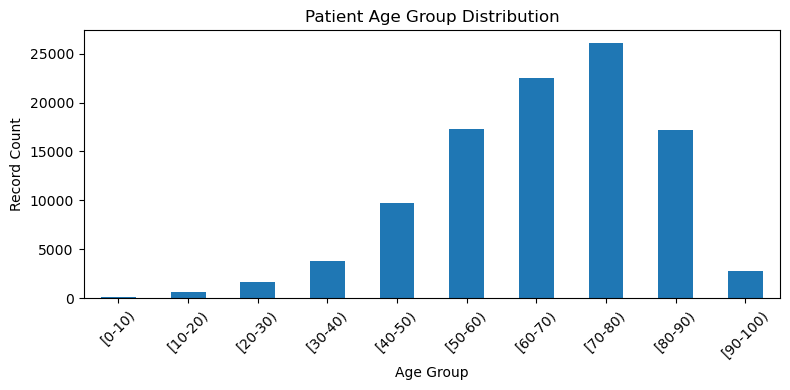

In [17]:
# ============================================================
# 17. Age Distribution Visualization
# ============================================================
# Philosophy:
#
# Age is clinically relevant because readmission
# risk may vary across patient age groups.
#
# This chart shows whether the dataset includes a
# broad patient age range and whether certain age
# groups dominate the dataset.
# ============================================================

age_counts = eda_df["age"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
age_counts.plot(kind="bar")
plt.title("Patient Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Record Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

age
[0-10)      0.018634
[10-20)     0.057887
[20-30)     0.142426
[30-40)     0.112318
[40-50)     0.106040
[50-60)     0.096662
[60-70)     0.111284
[70-80)     0.117731
[80-90)     0.120835
[90-100)    0.110992
Name: readmitted_binary, dtype: float64

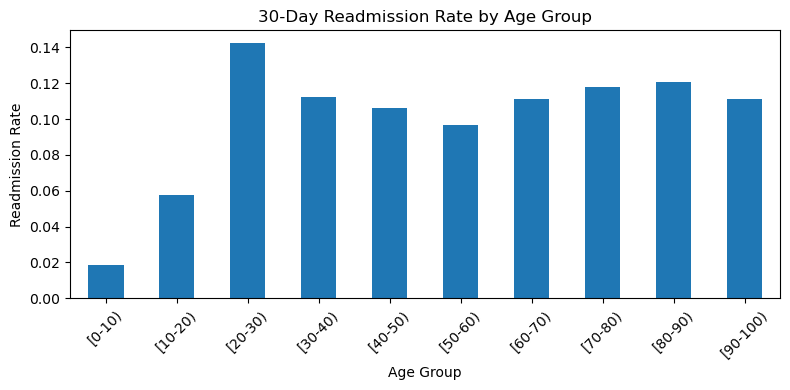

In [18]:
# ============================================================
# 18. Readmission Rate by Age Group
# ============================================================
# Philosophy:
#
# This analysis compares 30-day readmission rate
# across age groups.
#
# It helps evaluate whether age may provide useful
# predictive signal for the model.
# ============================================================

age_readmission_rate = (
    eda_df.groupby("age")["readmitted_binary"]
    .mean()
    .sort_index()
)

display(age_readmission_rate)

plt.figure(figsize=(8, 4))
age_readmission_rate.plot(kind="bar")
plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

number_inpatient
0     0.084371
1     0.129245
2     0.174333
3     0.202873
4     0.236128
5     0.314039
6     0.345833
7     0.354478
8     0.443709
9     0.423423
10    0.426230
11    0.673469
12    0.500000
13    0.500000
14    0.400000
Name: readmitted_binary, dtype: float64

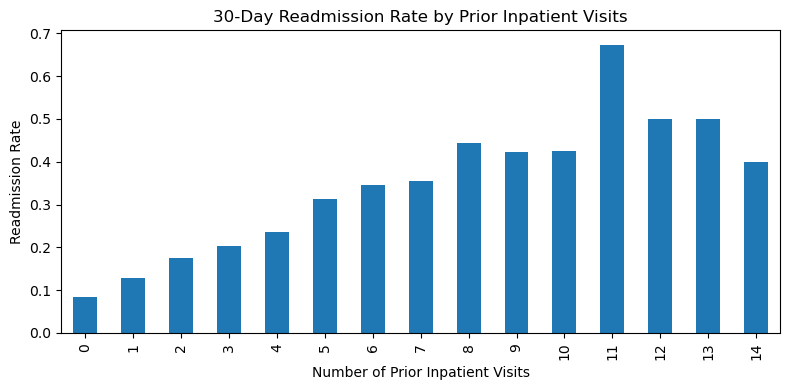

In [19]:
# ============================================================
# 19. Readmission by Prior Inpatient Visits
# ============================================================
# Philosophy:
#
# Prior inpatient visits may indicate recurring
# health issues or unstable care patterns.
#
# This analysis checks whether readmission rate
# changes as the number of prior inpatient visits
# increases.
# ============================================================

inpatient_rate = (
    eda_df.groupby("number_inpatient")["readmitted_binary"]
    .mean()
)

display(inpatient_rate.head(15))

plt.figure(figsize=(8, 4))
inpatient_rate.head(15).plot(kind="bar")
plt.title("30-Day Readmission Rate by Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Readmission Rate")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 20. Class Imbalance Summary
# ============================================================
# Philosophy:
#
# Class imbalance matters because relatively few
# patients are readmitted within 30 days.
#
# This supports using class imbalance handling in
# the XGBoost training script.
# ============================================================

negative_count = (
    eda_df["readmitted_binary"] == 0
).sum()

positive_count = (
    eda_df["readmitted_binary"] == 1
).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class count:", negative_count)
print("Positive class count:", positive_count)
print("Estimated scale_pos_weight:", scale_pos_weight)

Negative class count: 90409
Positive class count: 11357
Estimated scale_pos_weight: 7.960641014352381


In [21]:
# ============================================================
# 21. Feature Store Helper Function
# ============================================================
# Philosophy:
#
# SageMaker Feature Store provides a centralized
# place to manage engineered features.
#
# In this project, Feature Store is demonstrated as
# a feature governance and reuse layer.
#
# The training pipeline uses the same engineered
# feature logic, but it does not directly train from
# Feature Store in this student version.
# ============================================================

def clean_feature_name(col):
    col = str(col)
    col = re.sub(r"[^a-zA-Z0-9]", "_", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")

    if not re.match(r"^[a-zA-Z0-9]", col):
        col = "f_" + col

    return col[:64]


def create_or_reuse_feature_group(
    df_features,
    bucket_name,
    region,
    role,
    feature_group_name,
    run_ingestion=False
):
    sm_client = boto3.client(
        "sagemaker",
        region_name=region
    )

    featurestore_runtime = boto3.client(
        "sagemaker-featurestore-runtime",
        region_name=region
    )

    df_features = df_features.copy()

    if "record_id" not in df_features.columns:
        df_features["record_id"] = df_features.index.astype(str)

    if "event_time" not in df_features.columns:
        df_features["event_time"] = pd.Timestamp.utcnow().strftime(
            "%Y-%m-%dT%H:%M:%SZ"
        )

    for col in df_features.columns:
        if df_features[col].dtype == "bool":
            df_features[col] = df_features[col].astype(int)

    feature_definitions = []

    for col in df_features.columns:

        if col == "event_time":
            feature_type = "String"

        elif pd.api.types.is_integer_dtype(df_features[col]):
            feature_type = "Integral"

        elif pd.api.types.is_float_dtype(df_features[col]):
            feature_type = "Fractional"

        else:
            feature_type = "String"

        feature_definitions.append({
            "FeatureName": col,
            "FeatureType": feature_type
        })

    try:
        sm_client.describe_feature_group(
            FeatureGroupName=feature_group_name
        )

        print("Feature Group already exists:")
        print(feature_group_name)

    except sm_client.exceptions.ResourceNotFound:

        sm_client.create_feature_group(
            FeatureGroupName=feature_group_name,
            RecordIdentifierFeatureName="record_id",
            EventTimeFeatureName="event_time",
            FeatureDefinitions=feature_definitions,
            OfflineStoreConfig={
                "S3StorageConfig": {
                    "S3Uri": f"s3://{bucket_name}/feature-store/"
                },
                "DisableGlueTableCreation": False
            },
            RoleArn=role
        )

        print("Creating Feature Group:")
        print(feature_group_name)

    while True:
        response = sm_client.describe_feature_group(
            FeatureGroupName=feature_group_name
        )

        status = response["FeatureGroupStatus"]

        print("Feature Group status:", status)

        if status == "Created":
            break

        if status in ["CreateFailed", "DeleteFailed"]:
            raise Exception(
                f"Feature Group failed with status: {status}"
            )

        time.sleep(30)

    if run_ingestion:
        for i, row in df_features.iterrows():

            record = []

            for col, value in row.items():

                if pd.isna(value):
                    value = ""

                record.append({
                    "FeatureName": col,
                    "ValueAsString": str(value)
                })

            featurestore_runtime.put_record(
                FeatureGroupName=feature_group_name,
                Record=record
            )

            if i % 1000 == 0:
                print(f"Ingested {i} records...")

        print("Feature data ingested into SageMaker Feature Store.")

    else:
        print("Skipping ingestion because run_ingestion = False.")

    print("Feature Group Name:", feature_group_name)
    print("Offline Store Path:", f"s3://{bucket_name}/feature-store/")

    return feature_group_name

In [22]:
# ============================================================
# 22. Prepare Feature Store Dataset
# ============================================================
# Philosophy:
#
# This cell creates a small engineered feature
# sample for Feature Store demonstration.
#
# The feature engineering logic mirrors the model
# preprocessing logic:
#
# - replace "?" with NaN
# - convert the target
# - one-hot encode categorical features
# - clean feature names
#
# To control runtime and cost, only a sample is used
# for Feature Store setup.
# ============================================================

df_feature_sample = df_clean.sample(
    n=1000,
    random_state=RANDOM_STATE
).reset_index(drop=True)

df_feature_model_raw = df_feature_sample[
    FEATURES + ["readmitted_binary"]
].copy()

X_feature = df_feature_model_raw.drop(
    columns=["readmitted_binary"]
)

y_feature = df_feature_model_raw["readmitted_binary"]

X_feature_encoded = pd.get_dummies(
    X_feature,
    drop_first=True
)

X_feature_encoded.columns = [
    clean_feature_name(col)
    for col in X_feature_encoded.columns
]

df_feature_store = X_feature_encoded.copy()

df_feature_store["readmitted_binary"] = y_feature.values

df_feature_store["record_id"] = df_feature_store.index.astype(str)

df_feature_store["event_time"] = pd.Timestamp.utcnow().strftime(
    "%Y-%m-%dT%H:%M:%SZ"
)

for col in df_feature_store.columns:
    if df_feature_store[col].dtype == "bool":
        df_feature_store[col] = df_feature_store[col].astype(int)

print("Feature Store dataset shape:")
print(df_feature_store.shape)

display(df_feature_store.head())

Feature Store dataset shape:
(1000, 38)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,A1Cresult_8,A1Cresult_Norm,change_No,diabetesMed_Yes,insulin_No,insulin_Steady,insulin_Up,readmitted_binary,record_id,event_time
0,1,1,6,11,68,0,20,0,0,0,...,0,0,1,1,0,1,0,0,0,2026-06-19T08:40:03Z
1,1,1,1,1,20,0,7,0,0,0,...,0,0,1,1,1,0,0,0,1,2026-06-19T08:40:03Z
2,3,6,1,4,21,3,23,1,0,2,...,0,0,1,1,1,0,0,0,2,2026-06-19T08:40:03Z
3,2,1,1,12,28,0,19,0,0,1,...,0,0,1,1,1,0,0,0,3,2026-06-19T08:40:03Z
4,1,2,7,1,21,0,6,0,0,0,...,0,0,1,1,1,0,0,1,4,2026-06-19T08:40:03Z


In [23]:
# ============================================================
# 23. Create or Reuse SageMaker Feature Group
# ============================================================
# Philosophy:
#
# This cell creates or reuses the Feature Group for
# the engineered diabetes features.
#
# Ingestion is optional to avoid unnecessary cost.
#
# A screenshot of this Feature Group can be used in
# the final report and video demonstration.
# ============================================================

created_feature_group_name = create_or_reuse_feature_group(
    df_features=df_feature_store,
    bucket_name=BUCKET_NAME,
    region=REGION,
    role=role,
    feature_group_name=FEATURE_GROUP_NAME,
    run_ingestion=False
)

print("Feature Store setup complete:")
print(created_feature_group_name)

Feature Group already exists:
diabetes-readmission-feature-group


Feature Group status: Created
Skipping ingestion because run_ingestion = False.
Feature Group Name: diabetes-readmission-feature-group
Offline Store Path: s3://aai540-diabetes-readmission-468962265940/feature-store/
Feature Store setup complete:
diabetes-readmission-feature-group
